In [1]:
# PostgreSQL에서 clean_orders 데이터 불러오기
import pandas as pd
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os
import urllib.parse
import matplotlib.pyplot as plt

load_dotenv('.env')  # .env 파일 읽기

# DB연결정보
user = "postgres"
password = urllib.parse.quote_plus(os.getenv('DB_PW'))
host = "127.0.0.1"
port = '5432'
database = 'ecommerce'

# 엔진 생성
engine = create_engine(f'postgresql://{user}:{password}@{host}:{port}/{database}')

# 데이터 불러오기
data = pd.read_sql("select * from clean_orders", engine)

# 데이터 전처리
order_completed = data[data['order_status']=='Delivered to buyer']
df = order_completed.dropna(subset=['item_total'])


# 가설 1 : 매출은 소수 고객에게 집중되어 있을 것이다.

상위 10%의 고객이 전체 매출의 상당 부분을 차지할 것으로 예상했다.

이를 확인하기 위해 고객별 총 매출을 집계한 뒤, 상위 10% 고객의 매출 비중을 계산하였다.

In [2]:
# 고객별 총 매출 집계
customer_sales = df.groupby('buyer')['item_total'].sum()

# 고객별 총 매출 집계 내림차순
sort_customer_sales = customer_sales.sort_values(ascending=False)

# 상위 10% 고객 수
top_ten = int(len(sort_customer_sales)*0.1)

# 상위 10% 고객의 매출
top_customer = sort_customer_sales.iloc[:top_ten].sum()
top_ten_ratio = (top_customer / (customer_sales.sum())) * 100

print('상위 10% 고객 배출 비중 계산 :',top_ten_ratio)

상위 10% 고객 배출 비중 계산 : 29.06691187189522


### [분석결과]
상위 10% 고객은 전체 매출의 약 30%를 차지했다.

이는 매출이 일부 고객에게 집중되어 있으나, 극단적인 구조라고 보기 어렵다.

### [비즈니스 시사점]
- 매출이 소수 고객에게 극단적으로 의존하고 있지않고 비교적 분산되어 있는 구조를 보인다. 따라서 특정 고객 이탈에 크게 흔들리지 않을 가능성이 높다.
- 상위 고객의 구매 빈도를 추가적으로 높이는 전략을 통해 매출 확대 가능성이 존재한다.
- 또한, 상위 고객뿐만 아니라 비교적 매출이 적은 고객들의 구매 빈도 증가 전략을 통해 지금보다 매출을 안정적으로 확대할 수 있는 가능성이 있다.


# 가설 2 : 연말엔 소비 증가로 인해 월 평균 대비 매출이 높을 것이다.
연말(11월,12월)의 매출이 월 평균 대비 매출이 높을 것이라고 예상했다.

이를 확인하기 위해 월별 매출 추이를 계산하고, 연말(11월+12월) 매출 수준을 구하였다.

C:\Users\82104\AppData\Local\Temp\ipykernel_15876\379457868.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['year_month'] = df['order_date'].dt.to_period('M')


연말 평균 매출이 전체 월 평균 대비 비율: 320.90731266927475


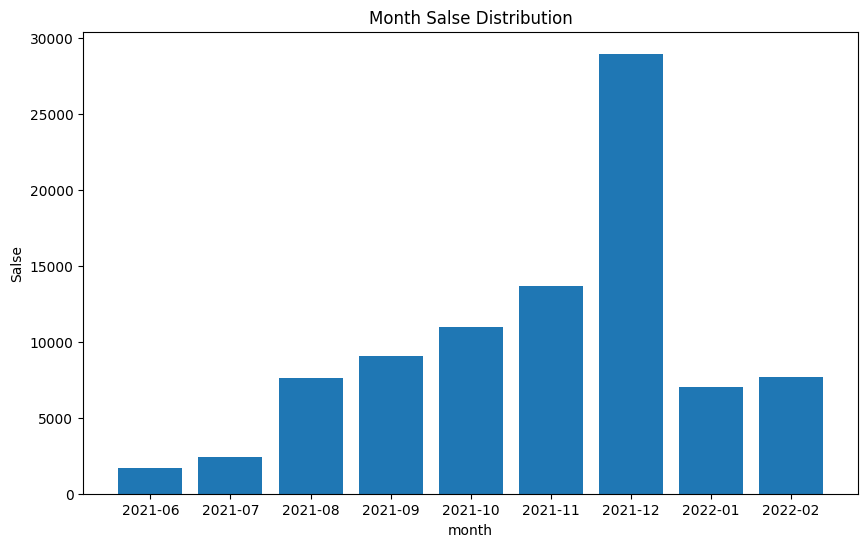

In [ ]:
# 월별 매출 추이 그래프
df['year_month'] = df['order_date'].dt.to_period('M')
month_sales = df.groupby('year_month')['item_total'].sum()
plt.figure(figsize=(10,6))
plt.bar(month_sales.index.astype(str),month_sales.values)
plt.xlabel('month')
plt.ylabel('Salse')
plt.title('Month Salse Distribution')

# 연말(11월+12월) 매출 수준
# 11월,12월을 제외한 월 매출 평균
avg_except_year_end = month_sales.drop(['2021-11','2021-12']).mean()

# 11월,12월 매출 평균
year_end_avg = (month_sales['2021-11'] + month_sales['2021-12']) / 2

# 연말 매출 비율 계산
ratio = (year_end_avg / avg_except_year_end) * 100

print("연말 매출 비율:", ratio)


### [분석결과]
2021년 11월, 2021년 12월 매출이 기타 월 평균 매출 대비 약 320% 높은 수준으로 나타났다.

그리고 Month Salse Distribution 그래프를 보면, 2021년 12월 매출이 다른 기간 매출보다 높은 것을 확인할 수 있다.

다만, 분석 데이터가 9개월로 제한되어 있어 추가적인 데이터 수집이 필요하다.

### [비즈니스 시사점]
- 연말에 수요가 집중되는 패턴을 가지고 있어, 연말 프로모션 기획과 같은 전략으로 매출 확대 가능성을 보인다.
- 연말엔 수요가 증가하므로, 충분한 재고 확보가 필요하다.

# 가설 3 : 재구매 고객은 전체 매출에서 높은 비중을 차지할 것이다.
재구매 고객의 매출이 전체 매출에서 높은 비중을 차지할 것이라고 예상했다.

이를 확인하기 위해 전체 고객에서 재구매 고객의 비율을 계산하고, 재구매 고객의 매출 비율을 구하였다.

In [ ]:
# 재구매 고객 비율 => 2회 이상 구매한 고객의 비율 구하기
# 고객별 구매 횟수
repeat_customer = df.groupby('buyer').size().reset_index(name='purchase_count')

# 2회 이상 구매한 고객
repeat_customers = repeat_customer[repeat_customer['purchase_count'] >= 2]

# 2회 이상 구매한 고객의 비율
repeat_customer_ratio = (repeat_customers['buyer'].count() / repeat_customer['buyer'].count()) * 100
print("2회 이상 구매한 고객의 비율 :",repeat_customer_ratio)


# 재구매 고객 매출 비율 구하기
# 전체 매출
customer_sales = df.groupby('buyer')['item_total'].sum()

# 재구매 고객 매출
repeat_customer_salse = customer_sales[repeat_customers['buyer']].sum()

# 재구매 고객 배출 비율
repeat_ratio = (repeat_customer_salse.sum()/customer_sales.sum()) * 100
print("재구매 고객 매출 비율 :",repeat_ratio.sum())

2회 이상 구매한 고객의 비율 : 12.5
재구매 고객 매출 비중 : 28.15748455319197


### [분석결과]
2회 이상 구매한 고객의 비율이 약 13%로 나타났다.

그중, 재구매 고객 매출의 비율은 전체 매출의 약 28%로 나타났다.


### [비즈니스 시사점]
- 재구매 고객은 전체 고객중 13%의 비율을 차지하지만, 재구매 고객의 매출 비율은 28%로, 재구매 고객 1명이 일반 고객보다 평균적으로 더 많은 매출을 만든다.
- 따라서, 재구매 고객을 타깃으로 한 전략이 매출 증대에 중요한 요소이다.

# 전체적인 분석 정리
매출이 소수 고객에게 과도하게 의존하고 있지 않고 분산되어 있는 안정적인 구조를 보인다.

다만, 연말 시즌 매출이 평균 대비 약 320%로 연말에 수요가 집중되어 있는 특징이 있으며, 

재구매 고객은 전체 고객중 13%의 비율을 차지하지만, 재구매 고객의 매출 비율은 28%로, 일반 고객보다 더 많은 매출을 만든다.

따라서 연말 시즌 마케팅 강화와 재구매 고객의 수요 증가 전략, 재구매 고객 유지 전략이 매출 성장에 효과적일 것이다.